###

# Factor graphs

## Introduction

```
Graphs  - nodes/vertices, edges
        - directed/undirected
        - Neighbors (vertices connected with edges)
```

In [ ]:
Factor graphs:
- Variables nodes (unknowns)
- Factor nodes (known constraints such as priors, odomtery or measurements)
- Edges (connects factors to variables. No meaning)
- Bipartite (variable-factor-variable)

In [ ]:
Variable interaction graphs
- Factor graph converted to plain undirected graph over variables only 
(factors removed as they sit on the edges you just have to remove the black dots)
- Connect two variables that have appear together in a factor graph

In [ ]:
Paths and cycles
- Sequence of edges connecting nodes is a path
- Path that starts and ends at the same node is a cycle. x1-x2-l1-x1

In [ ]:
Clique
- Set of nodes where every pair is connected by an edge (fully connected subgraph)
x1-x2-l1 is a clique (a 3-clique)

Maximnal Clique
A clique is maximal if you cant add another node and have a clique. For eg. adding x3 
to {x1,x2,l1} because x3 isnt connected to x1 or l1. So {x1,x2,l1} is a maximal clique

Basically if we see any subset of a clique is a clique as well. Hence the biggest set 
that contains all these cliques is maximal

In [ ]:
Frontal variables and Separators
p(x1|x2,l1) has x1 as frontal variable and x2, l1 as separator

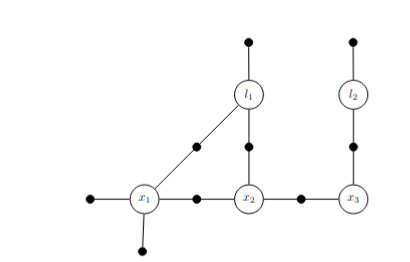

Factor graph connecting x1, x2, x3 odomtery poses with two landmarks l1 and l2

Factor graph formation for the estimation problem is MAP inference. You are given measurements/data and you have to find p(x|z) which means finding the most probable parameters/variables given your data/measurements. 

$$
\begin{aligned}
X^{MAP} &= \underset{X}{\mathrm{argmax}} \, p(X|Z) \\
&= \underset{X}{\mathrm{argmax}} \frac{p(Z|X)p(X)}{p(Z)}
\end{aligned}
$$
where p(Z) can be omitted since it does not depend on X.

$$p(X|Z) \propto p(x_1)p(x_2|x_1)p(x_3|x_2)$$
$$\times p(l_1)p(l_2)$$
$$\times l(x_1; z_1)$$
$$\times l(x_1, l_1; z_2)l(x_2, l_1; z_3)l(x_3, l_2; z_4).$$


When working with factor graphs factors are proportional to the above probabilities as can be seen from the below equation. The product of the factors in a factor graph defines a global function which is a measure of joint probability p(X|Z). The factor values need only be proportional to corresponding probability densities: any normalization constant that do not depend on the state variables may be omitted without consequence. 

$$\phi(l_1, l_2, x_1, x_2, x_3) = \phi_1(x_1)\phi_2(x_2, x_1)\phi_3(x_3, x_2)$$
$$\times \phi_4(l_1)\phi_5(l_2)$$
$$\times \phi_6(x_1)$$
$$\times \phi_7(x_1, l_1)\phi_8(x_2, l_1)\phi_9(x_3, l_2),$$


$$
\begin{aligned}
X^{MAP} &= \underset{X}{\mathrm{argmax}} \, \phi(X) \\
&= \underset{X}{\mathrm{argmax}} \prod_{i}{\phi_{i}(X_{i})}
\end{aligned}
$$

The first assumption to make the problem tractable is gaussian noise in measurements, odometry and priors.

$$\phi_i(X_i) \propto \exp \left\{ -\frac{1}{2} \| h_i(X_i) - z_i \|^2_{\Sigma_i} \right\},$$
Taking negative log and converting the problem into a minimization problem we get
$$X^{MAP} = \underset{X}{\mathrm{argmin}} \sum_i \| h_i(X_i) - z_i \|^2_{\Sigma_i}.$$


The measurement function $h$ above in most cases are non linear. To make this tractable we linearize it and convert the minimization problem on $X$ into a minimization problem on $\Delta$
$$h_i(X_i) = h_i(X_i^0 + \Delta_i) \approx h_i(X_i^0) + H_i\Delta_i,$$

$$H_i \triangleq \left. \frac{\partial h_i(X_i)}{\partial X_i} \right|_{X_i^0},$$

$$
\begin{aligned}
\Delta^* &= \underset{\Delta}{\mathrm{argmin}} \sum_i \left\| h_i(X_i^0) + H_i\Delta_i - z_i \right\|^2_{\Sigma_i} \\
&= \underset{\Delta}{\mathrm{argmin}} \sum_i \left\| H_i\Delta_i - \{z_i - h_i(X_i^0)\} \right\|^2_{\Sigma_i},
\end{aligned}
$$
$$\|e\|_{\Sigma}^2 \triangleq e^\top \Sigma^{-1} e = \left( \Sigma^{-1/2} e \right)^\top \left( \Sigma^{-1/2} e \right) = \left\| \Sigma^{-1/2} e \right\|_2^2.$$

$$
\begin{aligned}
A_i &= \Sigma_i^{-1/2} H_i \\
b_i &= \Sigma_i^{-1/2} \left( z_i - h_i(X_i^0) \right).
\end{aligned}
$$

$$
\begin{aligned}
\Delta^* &= \underset{\Delta}{\mathrm{argmin}} \sum_i \| A_i \Delta_i - b_i \|_2^2 \\
&= \underset{\Delta}{\mathrm{argmin}} \| A\Delta - b \|_2^2,
\end{aligned}
$$
where the last term is obtained by stacking individual factor jacobians and residuals in a big matrix.

This problem needs to be formulated and solved for non-linear optimization at each iteration with the first iteration getting linearized at the initial estimate and each successive linearization happening at the current best estimate. The methods to solve a non linear problem is:
1. Steepest descent: Basically gradient descent. Have to choose step size wisely.
$$\Delta_{sd} = -\alpha \left. \nabla g(X) \right|_{X=X^t}$$

$$g(X) \approx \| A(X - X^t) - b \|_2^2$$

$$\left. \nabla g(X) \right|_{X=X^t} = -2A^\top b$$

2. Gauss newton:
Gauss newton approximates hessian by $A^\top A$ and solves
$$A^\top A \Delta_{gn} = A^\top b$$
The objective function should be nearly quadratic with a good initial estimate for GN to work.

3. LM:
$ \lambda \in \mathbb{R}^+ \cup \{0\} $

$$ (A^\top A + \lambda I) \Delta_{lb} = A^\top b $$

Note that for $ \lambda = 0 $ we obtain GN, and for large $ \lambda $ we approximately obtain 
$ \Delta^* \approx \frac{1}{\lambda} A^\top b $, an update in the negative gradient direction of the cost function. Hence LM can be seen to blend naturally between the GN and SD methods.

$$ (A^\top A + \lambda \text{diag}(A^\top A)) \Delta_{lm} = A^\top b $$

In LM, lambda is heuristically changed when an update is rejected(its made higher) so that smaller steps are made. If update passes then lambda is decreased to make larger steps. 

$ A^\top A $ approximates the hessian. If surface is flat then hessian eigenvalues are small which means diagonal of $ A^\top A $ is small. Hence del_lm = $\frac{1}{\lambda}diag(A^\top A)^{-1} A^\top b$ is large. 

### Batch Inference

There are two ways to solve this optimization problem specifically the problem $A^\top A \Delta_{gn} = A^\top b$ (since gradient descent part in LM and SD is computationally easieras it does not include inverses):
1. Using sparse matrix factorization such as QR and Cholesky decomposition. This approach runs cholesky or QR to solve for updates in each iteration or non linear optimization. We dont compute Q and R matrices for [A|b] specifically however we use householders reflection to get R directly as in: 
$$H_n \cdots H_2 H_1 A = Q^\top A = \begin{bmatrix} R \\ \mathbf{0} \end{bmatrix}. $$
$$H_n \cdots H_2 H_1 [A|b] = Q^\top [A|b] = \begin{bmatrix} R \ d \\ \mathbf{0} \ e \end{bmatrix}. $$

$$\|A \boldsymbol{\delta} - b\|_2^2 = \|Q^\top A \boldsymbol{\delta} - Q^\top b\|_2^2 = \|R \boldsymbol{\delta} - d\|_2^2 + \|e\|_2^2, $$

$$R \boldsymbol{\delta}^* = d $$
which can be backsubstituted to get values of each $\delta^*$.

Cholesky also gives the same R as in
$$A^\top A = \begin{bmatrix} R \\ \mathbf{0} \end{bmatrix}^\top Q^\top Q \begin{bmatrix} R \\ \mathbf{0} \end{bmatrix} = R^\top R, $$

Since the system is sparse, how the column ordering of $A$ or $A^\top A$ is chosen effects the compute. All orders produce the same MAP solution but the variable order determines the fillin  of matrix factors R (both while using QR or cholesky). Heuristics like COLAMD is used to reduce the fill-ins and factorize the matrix efficiently.

2. Using graphical models such as factor graphs. See Elimination section for this below.
The above approaches are useful since SLAM problems are sparse in anture.

Approach 1 is mostly used for linear factors. Factor graphs can be used for non linear factors as well.

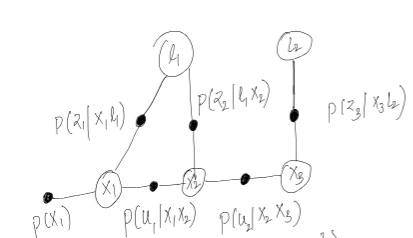

This seems to be the probabilities that the graph represents. p(z|x,l) is straightforward basically prob of measurement given pose and landmark where the measurement was taken. p(u|x1,x2) can be thought of as odometry measurement which was taken between x1 and x2 poses. I have not included priorson landmarks but that can be added as well.

For example for a graph like:


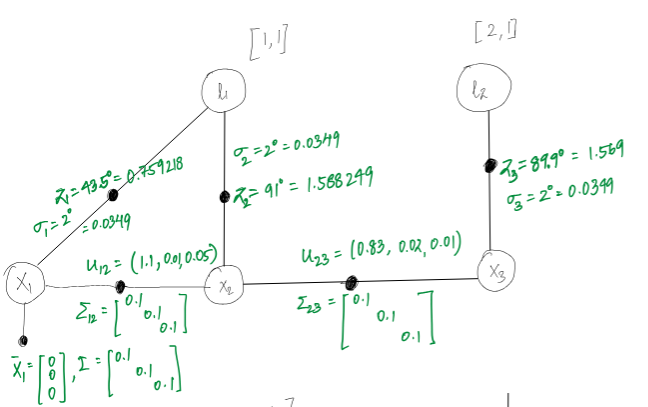

Considering an environment modelling like below:

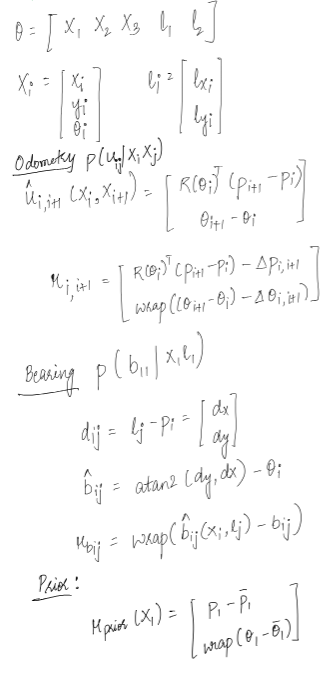

Using the above values for the poses and measurements we have: 

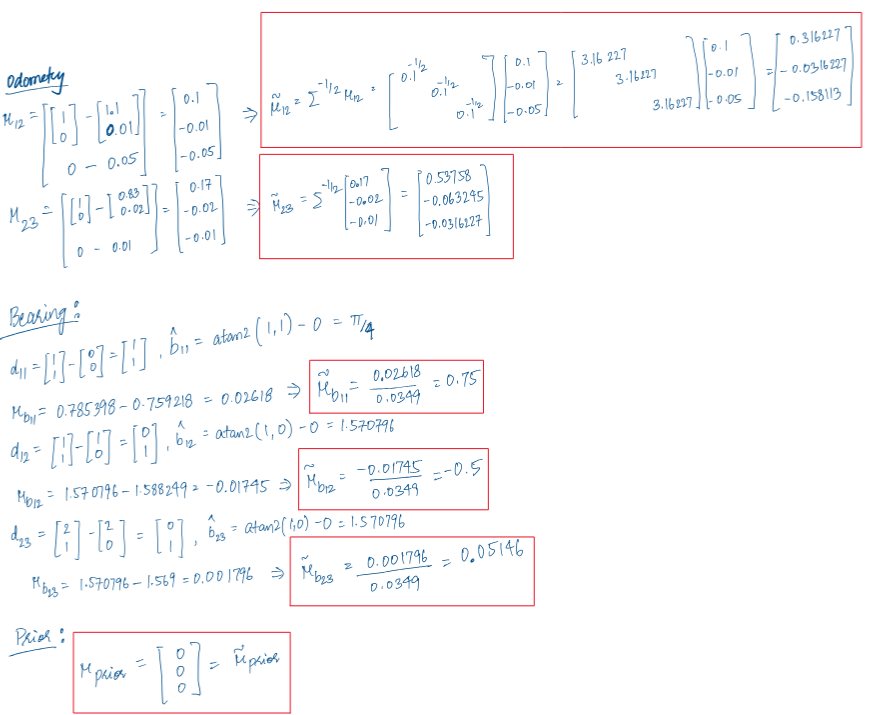

Objective

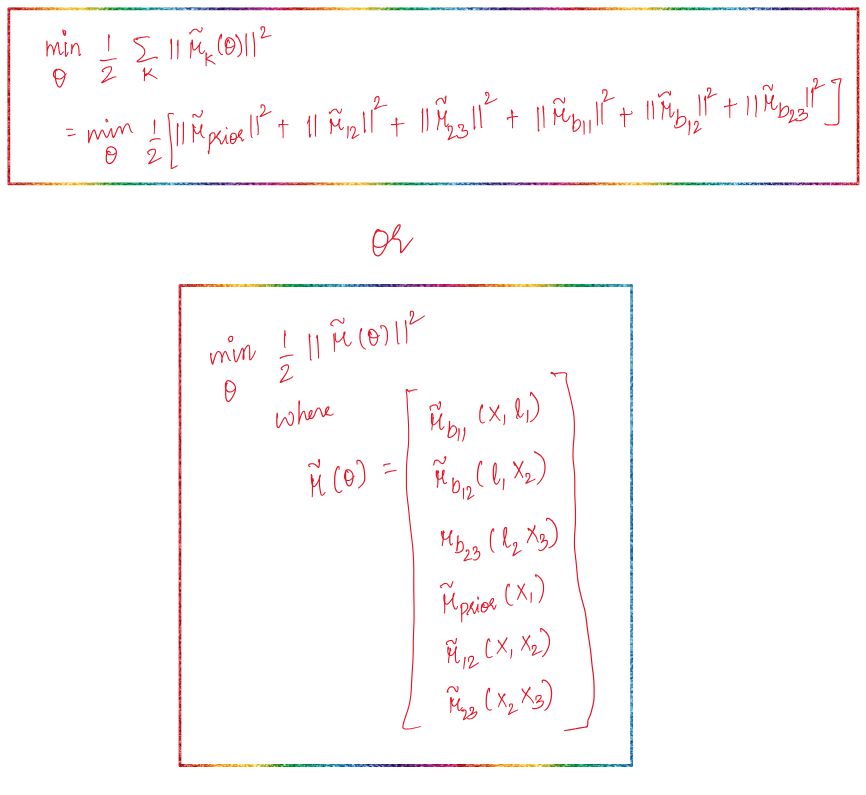

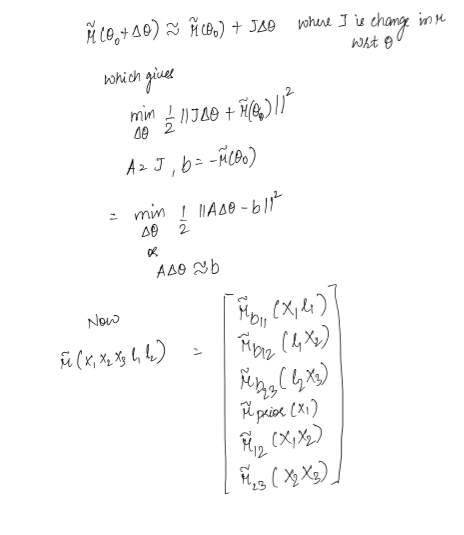

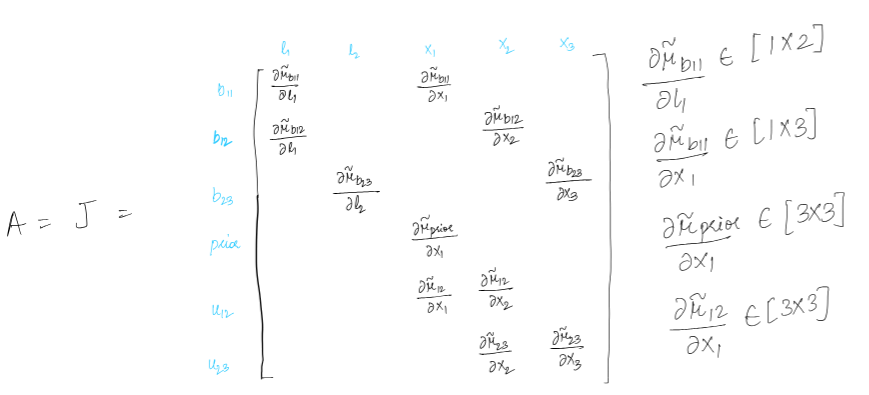

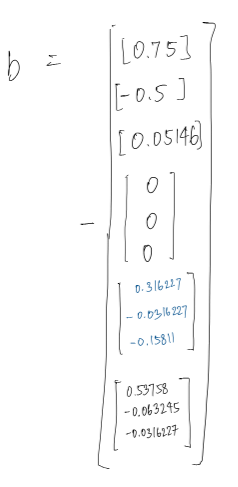

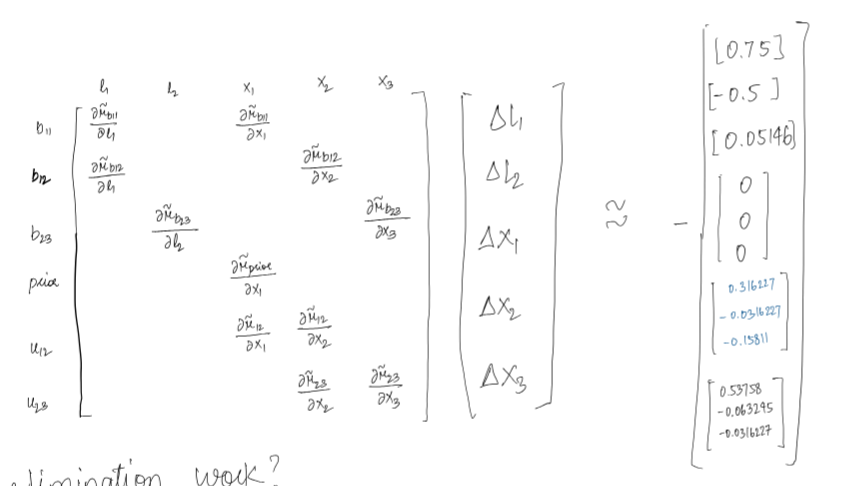

Jacobian of the factors is sparse and touches the variables involved in the factor. Hence A is sparse which means information matrix A transpose A is sparse as well. 

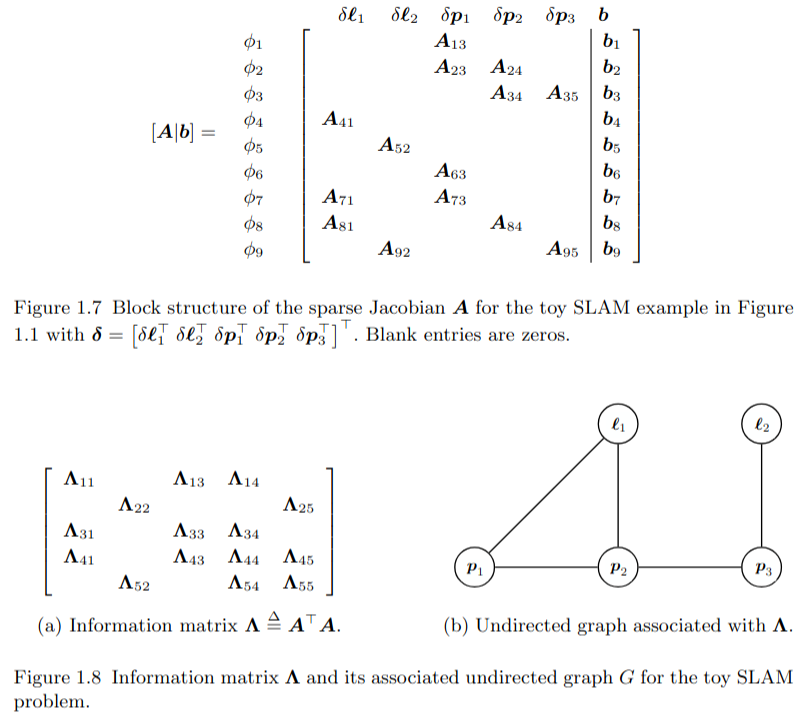

Elimination

A factor graph is converted into a Bayes net first. This removes the constraints and gives us a graph with only unknowns in it.

$$\phi(\boldsymbol{x}) = \phi(\boldsymbol{x}_1, \dots, \boldsymbol{x}_n)$$

$$p(\boldsymbol{x}) = p(\boldsymbol{x}_1 | \boldsymbol{s}_1) p(\boldsymbol{x}_2 | \boldsymbol{s}_2) \dots p(\boldsymbol{x}_n) = \prod_{j} p(\boldsymbol{x}_j | \boldsymbol{s}_j),$$


To eliminate a single variable $x_j$ given a partially eliminated factor graph $\phi_{j:n}$, we first remove all factors $\phi_i(x_i)$ that are adjacent to $x_j$ and multiply them into the product factor $\psi(x_j, s_j)$. We then factorize $\psi(x_j, s_j)$ into a conditional distribution $p(x_j|s_j)$ on the eliminated variable $x_j$, and a new factor $\tau(s_j)$ on the separator $s_j$:

$$\psi(x_j, s_j) = p(x_j|s_j)\tau(s_j). \tag{1.43}$$

The above equation is something I havent been able to understand. Why is this true?

The entire factorization from $\phi(\boldsymbol{x})$ to $p(\boldsymbol{x})$ is seen as a succession of n local factorization steps. When eliminating the last variable $x_{n}$ the separator $s_{n}$ will be empty, and the conditional produced will simply be a prior $p(x_{n})$ on $x_{n}$.

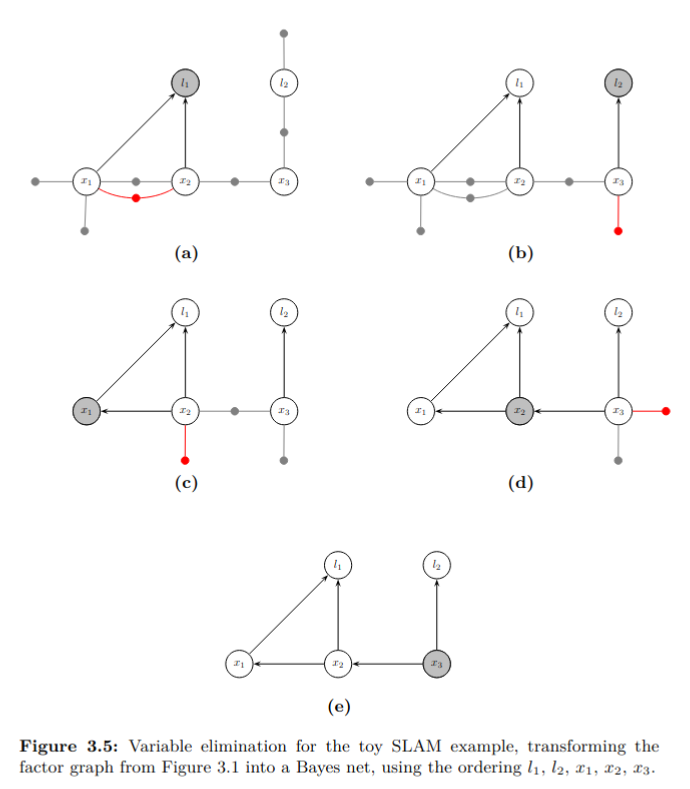

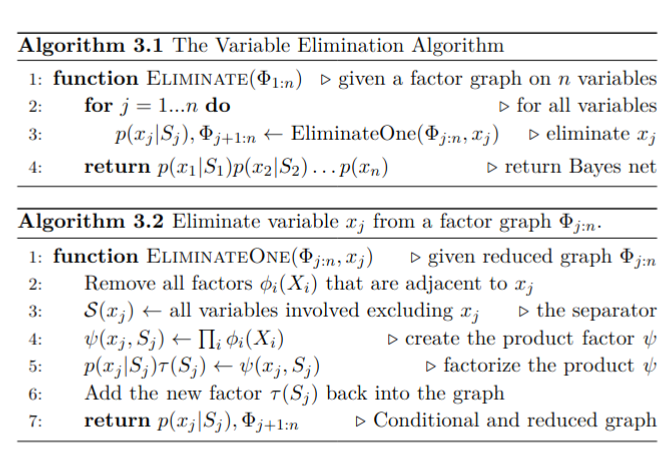

In the case of linear measurement functions and additive normally distributed noise, the elimination algorithm is equivalent to sparse matrix factorization. Both sparse Cholesky and QR factorization are a special case of the general algorithm.

The elimination algorithm proceeds one variable
at a time. Following Algorithm 3.2, for every variable $x_{j}$ we remove all
factors $\phi(X_{i})$ adjacent to $x_{j}$ , and form the intermediate product factor
$\psi(x_{j} , S_{j})$. This can be done by accumulating all the matrices $A_{i}$ into a
new, larger block-matrix $\bar{A_{j}}$ , as we can write
$$
\begin{aligned}
\psi(x_j, S_j) &\leftarrow \prod_i \phi_i(X_i) \\
&= \exp \left\{ -\frac{1}{2} \sum_i \| A_i X_i - b_i \|_2^2 \right\} \\
&= \exp \left\{ -\frac{1}{2} \| \bar{A}_j [x_j; S_j] - \bar{b}_j \|_2^2 \right\},
\end{aligned}
$$

where the new RHS vector $\bar{b}_j$ stacks all $b_i$.

**Example.** Consider eliminating the variable $l_1$ in the toy example. The adjacent factors are $\phi_4$, $\phi_7$ and $\phi_8$, in turn inducing the separator $S_1 = [x_1; x_2]$. The product factor is then equal to

$$ \psi(l_1, x_1, x_2) = \exp \left\{ -\frac{1}{2} \| \bar{A}_1 [l_1; x_1; x_2] - \bar{b}_1 \|_2^2 \right\}, \tag{3.16} $$

with

$$ \bar{A}_1 \triangleq \begin{bmatrix} A_{41} & & \\ A_{71} & A_{73} & \\ A_{81} & & A_{84} \end{bmatrix}, \quad \bar{b}_1 \triangleq \begin{bmatrix} b_4 \\ b_7 \\ b_8 \end{bmatrix}. \tag{3.17} $$


Factorizing the product $\psi(x_j, S_j)$ can be done in several different ways. Here we discuss the QR variant, as it more directly connects to the linearized factors. In particular, the augmented matrix $[\bar{A}_j|\bar{b}_j]$ corresponding to the product factor $\psi(x_j, S_j)$ can be rewritten using partial QR-factorization as follows:

$$ [\bar{A}_j|\bar{b}_j] = Q \begin{bmatrix} R_j & T_j & d_j \\ & \tilde{A}_\tau & \tilde{b}_\tau \end{bmatrix},  $$

where $R_j$ is an upper-triangular matrix. This allows us to factor $\psi(x_j, S_j)$ as follows:

$$
\begin{aligned}
\psi(x_j, S_j) &= \exp \left\{ -\frac{1}{2} \| \bar{A}_j [x_j; S_j] - \bar{b}_j \|_2^2 \right\}  \\
&= \exp \left\{ -\frac{1}{2} \| R_j x_j + T_j S_j - d_j \|_2^2 \right\} \exp \left\{ -\frac{1}{2} \| \tilde{A}_\tau S_j - \tilde{b}_\tau \|_2^2 \right\} \\
&= p(x_j|S_j)\tau(S_j), 
\end{aligned}
$$

where we used the fact that the rotation matrix $Q$ does not alter the value of the norms involved.The entire elimination algorithm, using partial QR to eliminate a single variable, is equivalent to sparse QR factorization.


This Gaussian factor graph corresponding to the linearized nonlinear problem is transformed by elimination into the density $P(X)$ given by the now familiar Bayes net factorization:

$$ P(X) = \prod_{j} p(x_j | S_j).  $$

In both QR and Cholesky variants, the conditional densities $p(x_j | S_j)$ are given by

$$ p(x_j | S_j) = k \exp \left\{ -\frac{1}{2} \| R_j x_j + T_j S_j - d_j \|_2^2 \right\},  $$

which is a linear-Gaussian density on the eliminated variable $x_j$. Indeed, we have

$$ \| R_j x_j + T_j S_j - d_j \|_2^2 = (x_j - \mu_j)^\top R_j^\top R_j (x_j - \mu_j) \triangleq \| x_j - \mu_j \|_{\Sigma_j}^2,  $$

where the mean $\mu_j = R_j^{-1}(d_j - T_j S_j)$ depends linearly on the separator $S_j$, and the covariance matrix is given by $\Sigma_j = (R_j^\top R_j)^{-1}$. Hence, the normalization constant $k = |2\pi\Sigma_j|^{-1/2}$.

After the elimination step is complete, back-substitution is used to obtain the MAP estimate of each variable. 
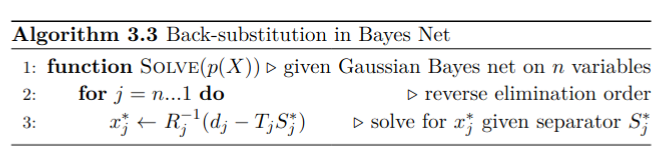

Reverse order is just since last eliminated variable has no separator and so on.


### Incremental Inference

The above two approaches for MAP inference: matrix factorization and Bayes net inference are both useful in batch optimization where you know the data in advance. If you are working in a incremental setting where you are receiving data in real-time, then you can incrementally update the matrix factorization for linear factors or Bayes net for non-linear factors. 

For our linear gaussian factor case , we have the objective function as

$$\|A\Delta - b\|_2^2 = \|R\Delta - d\|_2^2 + c, $$

where $c$ is a constant that reflects the sum of squared residuals of the least-squares problem.

When a new measurement arrives, instead of updating and refactoring a new system $A'|b'$ from scratch, we have the option to modify the previous factorization directly by **QR-updating**. Let us assume that $A'$ is formed by adding a single new measurement row $a^\top$ with corresponding RHS element $\beta$, i.e.,

$$A' = \begin{bmatrix} A \\ a^\top \end{bmatrix} \quad b' = \begin{bmatrix} b \\ \beta \end{bmatrix}. $$

Then a QR update proceeds as follows: adding $a^\top \in \mathbb{R}^n$ to the previous factor $R \in \mathbb{R}^{n \times n}$ and the new scalar element $\beta \in \mathbb{R}$ to the previous RHS $d$ yields a new system $R_a|d_a$ that is not yet in the correct factorized form:

$$R_a = \begin{bmatrix} R \\ a^\top \end{bmatrix} = \begin{bmatrix} Q^\top & \\ & 1 \end{bmatrix} \begin{bmatrix} A \\ a^\top \end{bmatrix} \quad d_a = \begin{bmatrix} d \\ \beta \end{bmatrix}. $$

A series of Givens rotations are applied to zero out the new row, starting from the left-most nonzero entry $(i, j_1)$ and resulting in an upper triangular matrix that contains the updated factor $R'$

$$ G_{j_k} \dots G_{j_2} G_{j_1} R_a = \begin{bmatrix} R' \\ 0 \end{bmatrix}. $$

After all is said and done, the incremental factorization is equivalent to rewriting the updated objective without re-factoring $A$, as desired:

$$ \| R' \Delta - d' \|_2^2 = \| A \Delta - b \|_2^2 + \| a \Delta - \beta \|_2^2 + c', $$



$$\|A\Delta - b\|_2^2 = \|R\Delta - d\|_2^2 + c, $$

where $c$ is a constant that reflects the sum of squared residuals of the least-squares problem.

When a new measurement arrives, instead of updating and refactoring a new system $A'|b'$ from scratch, we have the option to modify the previous factorization directly by **QR-updating**. Let us assume that $A'$ is formed by adding a single new measurement row $a^\top$ with corresponding RHS element $\beta$, i.e.,

$$A' = \begin{bmatrix} A \\ a^\top \end{bmatrix} \quad b' = \begin{bmatrix} b \\ \beta \end{bmatrix}. $$

Then a QR update proceeds as follows: adding $a^\top \in \mathbb{R}^n$ to the previous factor $R \in \mathbb{R}^{n \times n}$ and the new scalar element $\beta \in \mathbb{R}$ to the previous RHS $d$ yields a new system $R_a|d_a$ that is not yet in the correct factorized form:

$$R_a = \begin{bmatrix} R \\ a^\top \end{bmatrix} = \begin{bmatrix} Q^\top & \\ & 1 \end{bmatrix} \begin{bmatrix} A \\ a^\top \end{bmatrix} \quad d_a = \begin{bmatrix} d \\ \beta \end{bmatrix}. $$

A series of Givens rotations are applied to zero out the new row, starting from the left-most nonzero entry $(i, j_1)$ and resulting in an upper triangular matrix that contains the updated factor $R'$

$$ G_{j_k} \dots G_{j_2} G_{j_1} R_a = \begin{bmatrix} R' \\ 0 \end{bmatrix}. $$

After all is said and done, the incremental factorization is equivalent to rewriting the updated objective without re-factoring $A$, as desired:

$$ \| R' \Delta - d' \|_2^2 = \| A \Delta - b \|_2^2 + \| a \Delta - \beta \|_2^2 + c', $$



Two things to note here:
1. When we convert A to R (upper triangular) using QR, if we have A as mxn then R only has top nxn populated and bottom rows are 0. Hence you would notice the notation $\begin{bmatrix} R/R' \\ 0 \end{bmatrix}. $
2. When you do givens rotation check how $\begin{bmatrix} Q^\top & \\ & 1 \end{bmatrix}$ is still orthogonal after adding 1. Because of that check how $a^{T}$ and $\beta$ directly append into $R$ and $d$. 
3. There was a note saying you can non-zero out few entries in bottom row when you do givens rotation. Thats an artifact of givens. What givens does is that it takes the new row let say n+1 and in that i column. To zero out i column entry it mixes that row and i row in the matrix using 2D rotations.
$$ G = \begin{bmatrix} cos(\phi) & sin(\phi) \\ -sin(\phi) & cos(\phi) \end{bmatrix} $$
Since ith column already has [0,i) column entries zeroed out the already processed entries of last row dont alter. Only the entries who are to be processed later are affected which can be easily rotated when they are to be.

#### Approach 2:

The desire of generalizing incremental inference to nonlinear problems motivates the introduction of the Bayes tree graphical model. Matrix factorization operates on linear systems, but most inference problems in robotics of practical interest are nonlinear, including SLAM. In the incremental matrix factorization story it is
far from obvious how re-linearization can be performed incrementally without refactoring the complete matrix. To overcome this problem we investigate inference in graphical models, and introduce a new graphical model, the Bayes tree.

The main reason we are going for Bayes tree is the efficiency of inference in tree structured graphs. In case of Bayes net and factor graphs, cycles are present and inference is not trivial. Hence we follow a two step process of first converting the factor graph to a Bayes net using elimination and then converting the Bayes net to a Bayes tree. The Bayes net we get after elimination on factor graph has a special property; it is chordal which helps in converting it to a Bayes tree.

By identifying cliques (groups of fully connected variables) in this chordal graph, the Bayes net may be rewritten as a Bayes tree. 

More formally, a **Bayes tree** is a directed tree where the nodes represent **cliques** $C_k$ of the underlying chordal Bayes net. In particular, we define one conditional density $p(F_k|S_k)$ per node, with the **separator** $S_k$ as the intersection $C_k \cap \Pi_k$ of the clique $C_k$ and its parent clique $\Pi_k$. The **frontal variables** $F_k$ are the remaining variables, i.e. $F_k \triangleq C_k \setminus S_k$. We write $C_k = F_k : S_k$. The following expression gives the joint density $p(X)$ on the variables $X$ defined by a Bayes tree:

$$ p(X) = \prod_{k} p(F_k|S_k) $$

For the root $F_r$ the separator is empty, i.e., it is a simple prior $p(F_r)$ on the root variables. The way Bayes trees are defined, the separator is always a subset of parent clique and hence directed edges mean conditioning.
